# Diagnóstico Estatístico da Série Temporal

## 1. Objetivo do Notebook

O notebook de análise exploratória descreveu como a carga elétrica variou entre anos, meses, dias da semana, horários e subsistemas.

Nesta etapa, o objetivo é estudar as propriedades estatísticas da série temporal diária do Sistema Interligado Nacional (SIN). A análise buscará responder às seguintes perguntas:

- A série diária possui uma sequência temporal regular?
- Como sua média e sua variabilidade mudam ao longo do tempo?
- É possível separar tendência, sazonalidade semanal e sazonalidade anual?
- Quanto os valores atuais estão relacionados aos dias anteriores?
- A série é estacionária?
- A decomposição consegue explicar toda a estrutura temporal?

O notebook não realizará previsão e não utilizará modelos de Machine Learning. Cada conclusão será apresentada somente depois do código e do resultado que a sustentam.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller, kpss

pio.templates.default = 'plotly_white'
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../data/processed')


In [2]:
electric_data = pd.read_parquet(DATA_PATH / 'curva_carga_consolidado.parquet')

electric_data.head()


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiahomwmed
0,N,NORTE,2000-01-01 00:00:00,2373.7
1,NE,NORDESTE,2000-01-01 00:00:00,5340.2
2,S,SUL,2000-01-01 00:00:00,5777.0
3,SE,SUDESTE,2000-01-01 00:00:00,21183.0
4,N,NORTE,2000-01-01 01:00:00,2331.6


In [3]:
electric_data.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 911608 entries, 0 to 911607
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id_subsistema            911608 non-null  str           
 1   nom_subsistema           911608 non-null  str           
 2   din_instante             911608 non-null  datetime64[ns]
 3   val_cargaenergiahomwmed  911348 non-null  float64       
dtypes: datetime64[ns](1), float64(1), str(2)
memory usage: 34.1 MB


In [4]:
print(f'Quantidade de registros: {electric_data.shape[0]:,}')
print(f'Data inicial: {electric_data["din_instante"].min()}')
print(f'Data final: {electric_data["din_instante"].max()}')

Quantidade de registros: 911,608
Data inicial: 2000-01-01 00:00:00
Data final: 2025-12-31 23:00:00


- O arquivo possui 911.608 registros e quatro colunas. A coluna de data está no formato 'datetime64[ns]' e a carga está no formato numérico 'float64', conforme definido durante a consolidação.

- O período começa em 01/01/2000 às 00:00 e termina em 31/12/2025 às 23:00. Com o arquivo carregado, podemos construir a série do SIN que será utilizada neste diagnóstico.

## 2. Construção da Série Diária do SIN

Primeiro, os dados serão reorganizados para que cada horário corresponda a uma linha e cada subsistema a uma coluna. A carga do SIN será calculada somente quando as cargas dos quatro subsistemas estiverem disponíveis.


In [5]:
hourly_load = electric_data.pivot(
    index='din_instante', columns='id_subsistema', values='val_cargaenergiahomwmed'
)

hourly_load.head()


id_subsistema,N,NE,S,SE
din_instante,,,,
2000-01-01 00:00:00,2373.7,5340.2,5777.0,21183.0
2000-01-01 01:00:00,2331.6,5180.8,5580.7,20409.9
2000-01-01 02:00:00,2332.9,5068.6,5098.7,19787.4
2000-01-01 03:00:00,2311.6,4905.1,4753.7,19089.0
2000-01-01 04:00:00,2287.8,4811.7,4584.1,18589.1


In [6]:
hourly_load['carga_sin'] = hourly_load[['N', 'NE', 'S', 'SE']].sum(axis=1, min_count=4)

print(f'Horários presentes na tabela: {hourly_load.shape[0]:,}')
print(f'Horários com carga válida: {hourly_load["carga_sin"].notna().sum():,}')
print(f'Horários sem carga válida: {hourly_load["carga_sin"].isna().sum():,}')


Horários presentes na tabela: 227,914
Horários com carga válida: 227,837
Horários sem carga válida: 77


- A reorganização produziu 227.914 horários presentes na base. Entre eles, 227.837 possuem as quatro cargas necessárias para calcular o SIN e 77 permanecem sem carga total válida.

- Esses horários já foram investigados no notebook exploratório. Agora precisamos verificar como eles afetam a série após a agregação diária.


In [7]:
daily_load = hourly_load['carga_sin'].resample('D').mean()

daily_load.head()

din_instante
2000-01-01    30736.529167
2000-01-02    31453.354167
2000-01-03    37466.737500
2000-01-04    39149.970833
2000-01-05    39961.879167
Freq: D, Name: carga_sin, dtype: float64

In [8]:
print(f'Dias na sequência temporal: {daily_load.shape[0]:,}')
print(f'Data inicial: {daily_load.index.min()}')
print(f'Data final: {daily_load.index.max()}')
print(f'Dias sem carga média: {daily_load.isna().sum()}')

Dias na sequência temporal: 9,497
Data inicial: 2000-01-01 00:00:00
Data final: 2025-12-31 00:00:00
Dias sem carga média: 3


- A agregação criou uma sequência com 9.497 dias entre 2000 e 2025. Três posições estão sem carga média.

- O próximo resultado mostrará quais são essas datas. Ainda não será aplicado nenhum preenchimento.


In [9]:
daily_load[daily_load.isna()]

din_instante
2013-12-01   NaN
2014-02-01   NaN
2015-04-09   NaN
Name: carga_sin, dtype: float64

- Os três dias sem carga são 01/12/2013, 01/02/2014 e 09/04/2015. São as mesmas datas que apresentaram 24 horas sem carga total na análise exploratória.

- Além dos dias completamente vazios, precisamos verificar se existem médias calculadas com menos de 24 horas válidas.


In [10]:
valid_hours_by_day = hourly_load['carga_sin'].resample('D').count()

valid_hours_by_day.value_counts().sort_index()

carga_sin
0        3
23      19
24    9475
Name: count, dtype: int64

In [11]:
valid_hours_by_day[valid_hours_by_day < 24]

din_instante
2000-10-08    23
2001-10-14    23
2002-11-03    23
2003-10-19    23
2004-11-02    23
2005-10-16    23
2006-11-05    23
2007-10-14    23
2008-10-19    23
2009-10-18    23
2010-10-17    23
2011-10-16    23
2012-10-21    23
2013-10-20    23
2013-12-01     0
2014-02-01     0
2014-10-19    23
2015-04-09     0
2015-10-18    23
2016-10-16    23
2017-10-15    23
2018-11-04    23
Name: carga_sin, dtype: int64

A contagem mostrou três situações:

- 9.475 dias possuem 24 horas válidas;
- 19 dias possuem 23 horas válidas;
- 3 dias não possuem nenhuma hora válida.

- As datas com 23 horas coincidem com as transições de horário de verão documentadas no notebook anterior. Como esses dias possuem quase todas as observações e sua duração civil foi diferente, suas médias serão preservadas.

- Os três dias completamente vazios impedem a aplicação dos métodos de decomposição. Antes de preenchê-los, serão comparadas duas alternativas: a interpolação linear entre o dia anterior e o posterior e a média do mesmo dia da semana anterior e posterior.


In [12]:
missing_days = daily_load.index[daily_load.isna()]
linear_interpolation = daily_load.interpolate(method='time')

gap_comparison = []

for day in missing_days:
    previous_week = daily_load.loc[day - pd.Timedelta(days=7)]
    next_week = daily_load.loc[day + pd.Timedelta(days=7)]

    gap_comparison.append({
        'data': day,
        'dia_semana': day.day_name(),
        'dia_anterior': daily_load.loc[day - pd.Timedelta(days=1)],
        'dia_posterior': daily_load.loc[day + pd.Timedelta(days=1)],
        'mesmo_dia_semana_anterior': previous_week,
        'mesmo_dia_semana_posterior': next_week,
        'interpolacao_linear': linear_interpolation.loc[day],
        'media_mesmo_dia_semana': (previous_week + next_week) / 2
    })

gap_comparison = pd.DataFrame(gap_comparison).set_index('data')

gap_comparison.round(2)


,dia_semana,dia_anterior,dia_posterior,mesmo_dia_semana_anterior,mesmo_dia_semana_posterior,interpolacao_linear,media_mesmo_dia_semana
data,,,,,,,
2013-12-01,Sunday,59305.83,63138.35,51549.37,53797.76,61222.09,52673.57
2014-02-01,Saturday,71668.09,58893.35,62884.96,66805.90,65280.72,64845.43
2015-04-09,Thursday,64498.35,64861.16,65312.25,66370.41,64679.76,65841.33


- Os dois métodos produzem resultados próximos para 01/02/2014 e 09/04/2015, mas apresentam uma diferença relevante em 01/12/2013.

- Essa data foi um domingo. A interpolação linear entre sábado e segunda-feira resultaria em 61.222,09 MWmed, enquanto a média dos domingos anterior e posterior resulta em 52.673,57 MWmed.

- Como a análise exploratória mostrou que os domingos possuem um nível de carga diferente dos outros dias, será utilizada a média do mesmo dia da semana anterior e posterior. Esse preenchimento preserva melhor o ciclo semanal. Ele é uma aproximação técnica para tornar a série regular e não deve ser interpretado como o valor real que ocorreu nas datas ausentes.


In [13]:
daily_series = daily_load.copy()

for day in missing_days:
    daily_series.loc[day] = (
        daily_load.loc[day - pd.Timedelta(days=7)] + daily_load.loc[day + pd.Timedelta(days=7)]
    ) / 2

print(f'Frequência identificada: {pd.infer_freq(daily_series.index)}')
print(f'Dias na série: {daily_series.shape[0]:,}')
print(f'Valores ausentes: {daily_series.isna().sum()}')


Frequência identificada: D
Dias na série: 9,497
Valores ausentes: 0


- A série preparada possui frequência diária, 9.497 observações e nenhum valor ausente. Somente os três dias completamente vazios foram preenchidos; as médias dos 19 dias com 23 horas foram mantidas.

## 3. Estabilidade da Média e da Variabilidade

Uma série estacionária mantém propriedades como média e variância relativamente estáveis ao longo do tempo. Antes de aplicar testes estatísticos, vamos observar essas propriedades em janelas móveis de 365 dias.

A janela anual reduz oscilações de curto prazo e permite acompanhar mudanças graduais no nível e na dispersão da série.


In [14]:
rolling_statistics = pd.DataFrame({
    'media_movel': daily_series.rolling(365).mean(),
    'desvio_movel': daily_series.rolling(365).std()
})

rolling_statistics['cv_%'] = rolling_statistics['desvio_movel'] / rolling_statistics['media_movel'] * 100

rolling_statistics.dropna().head()


,media_movel,desvio_movel,cv_%
din_instante,,,
2000-12-30,40827.053581,3228.115982,7.906806
2000-12-31,40839.387918,3197.914740,7.830467
2001-01-01,40841.069564,3193.123265,7.818412
2001-01-02,40847.625499,3188.629586,7.806157
2001-01-03,40855.879485,3188.122274,7.803338


In [15]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=('Média móvel de 365 dias', 'Desvio-padrão móvel de 365 dias'),
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(
        x=rolling_statistics.index,
        y=rolling_statistics['media_movel'],
        name='Média móvel',
        line=dict(color='#636EFA')
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=rolling_statistics.index,
        y=rolling_statistics['desvio_movel'],
        name='Desvio-padrão',
        line=dict(color='#EF553B')
    ),
    row=2,
    col=1
)

fig.update_yaxes(title_text='Carga média (MWmed)', row=1, col=1)
fig.update_yaxes(title_text='Desvio-padrão (MWmed)', row=2, col=1)
fig.update_xaxes(title_text='Ano', row=2, col=1)
fig.update_layout(height=700, hovermode='x unified', showlegend=False)
fig.show()


- A média móvel não permanece constante: ela cresce no longo prazo e apresenta períodos de redução, estabilidade e aceleração.

- O desvio-padrão móvel também muda durante a série. Em alguns períodos, o crescimento do nível da carga é acompanhado por oscilações maiores em MWmed.

- Para medir a relação entre o nível médio e a dispersão absoluta, será calculada a correlação entre as duas medidas móveis.


In [16]:
rolling_statistics[['media_movel', 'desvio_movel']].corr().round(3)


,media_movel,desvio_movel
media_movel,1.00,0.88
desvio_movel,0.88,1.00


- A correlação entre a média móvel e o desvio-padrão móvel foi de 0,880. Isso mostra uma associação positiva forte: períodos com carga média maior também tendem a apresentar maior dispersão em valores absolutos.

- Entretanto, ainda precisamos verificar se a variabilidade também aumentou proporcionalmente. Para isso, será observado o coeficiente de variação móvel.


In [17]:
fig = px.line(
    x=rolling_statistics.index,
    y=rolling_statistics['cv_%'],
    title='Coeficiente de variação móvel da carga diária do SIN'
)

fig.update_traces(line_color='#AB63FA')
fig.update_layout(
    xaxis_title='Ano',
    yaxis_title='Coeficiente de variação (%)',
    hovermode='x unified',
    showlegend=False
)
fig.show()


In [18]:
cv = rolling_statistics['cv_%'].dropna()

print(cv.describe().round(2))
print()
print(f'Menor coeficiente: {cv.min():.2f}% em {cv.idxmin().date()}')
print(f'Maior coeficiente: {cv.max():.2f}% em {cv.idxmax().date()}')

count    9133.00
mean        8.63
std         1.08
min         7.17
25%         7.91
50%         8.42
75%         9.08
max        13.99
Name: cv_%, dtype: float64

Menor coeficiente: 7.17% em 2008-09-08
Maior coeficiente: 13.99% em 2002-01-06


- O coeficiente de variação móvel apresentou média de 8,63% e permaneceu entre 7,17% e 13,99% ao longo das janelas disponíveis.

- Portanto, a dispersão absoluta aumentou junto com o nível da carga, mas a variação proporcional permaneceu em uma faixa mais limitada. O maior afastamento ocorreu na janela que inclui 2001, período que já havia apresentado a maior redução anual na análise exploratória.

- Os gráficos confirmam que média e variabilidade não são completamente estáveis. A próxima etapa separará formalmente os componentes temporais presentes na série.

## 4. Decomposição da Série Temporal

A série diária pode apresentar mais de uma sazonalidade. Neste caso, serão avaliados dois períodos conhecidos pelo calendário e observados anteriormente:

- 7 dias, representando o ciclo semanal;
- 365 dias, representando uma aproximação do ciclo anual.

Será utilizada a decomposição MSTL, que permite extrair múltiplas sazonalidades. A opção robusta reduz a influência de dias muito atípicos durante a estimação dos componentes.


In [19]:
decomposition = MSTL(daily_series, periods=(7, 365), stl_kwargs={'robust': True}).fit()

decomposition.seasonal.head()


,seasonal_7,seasonal_365
din_instante,,
2000-01-01,-1916.123242,-6996.203393
2000-01-02,-5769.446435,-12262.259574
2000-01-03,1227.842136,-3492.047484
2000-01-04,1829.628272,-1937.489462
2000-01-05,1683.233579,-727.501857


- O resultado apresenta duas colunas sazonais: 'seasonal_7' e 'seasonal_365'. Isso confirma que o procedimento separou os ciclos semanal e anual solicitados.

- Primeiro, serão comparados os valores observados com a tendência estimada para todo o período.


In [20]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=daily_series.index,
        y=daily_series,
        name='Carga diária',
        line=dict(color='lightgray', width=1)
    )
)

fig.add_trace(
    go.Scatter(
        x=decomposition.trend.index,
        y=decomposition.trend,
        name='Tendência estimada',
        line=dict(color='#636EFA', width=2)
    )
)

fig.update_layout(
    title='Carga diária do SIN e tendência estimada pela decomposição',
    xaxis_title='Ano',
    yaxis_title='Carga média (MWmed)',
    hovermode='x unified'
)
fig.show()


In [21]:
component_summary = decomposition.seasonal.agg(['min', 'max', 'std']).T
component_summary['amplitude'] = component_summary['max'] - component_summary['min']

component_summary.round(2)


,min,max,std,amplitude
seasonal_7,-11398.74,4695.59,3744.24,16094.33
seasonal_365,-12262.26,9357.34,2576.34,21619.60


In [22]:
analysis_year = '2024'

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        'Carga observada e tendência',
        'Componente semanal',
        'Componente anual',
        'Resíduo'
    ),
    vertical_spacing=0.07
)

fig.add_trace(
    go.Scatter(
        x=daily_series.loc[analysis_year].index,
        y=daily_series.loc[analysis_year],
        name='Observado',
        line=dict(color='gray')
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=decomposition.trend.loc[analysis_year].index,
        y=decomposition.trend.loc[analysis_year],
        name='Tendência',
        line=dict(color='#636EFA')
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=decomposition.seasonal.loc[analysis_year].index,
        y=decomposition.seasonal.loc[analysis_year, 'seasonal_7'],
        name='Semanal',
        line=dict(color='#EF553B')
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=decomposition.seasonal.loc[analysis_year].index,
        y=decomposition.seasonal.loc[analysis_year, 'seasonal_365'],
        name='Anual',
        line=dict(color='#00CC96')
    ),
    row=3,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=decomposition.resid.loc[analysis_year].index,
        y=decomposition.resid.loc[analysis_year],
        name='Resíduo',
        line=dict(color='#EF553B')
    ),
    row=4,
    col=1
)

fig.update_yaxes(title_text='MWmed')
fig.update_xaxes(title_text='Data', row=4, col=1)
fig.update_layout(height=950, hovermode='x unified')
fig.show()


- A tendência estimada acompanha o crescimento de longo prazo e os períodos de redução ou estabilidade observados na carga diária.

- O componente semanal apresentou amplitude histórica de aproximadamente 16.094 MWmed. O componente anual apresentou amplitude de aproximadamente 21.620 MWmed.

- Na visualização de 2024, o componente semanal repete oscilações curtas ao longo do ano, enquanto o componente anual se move mais lentamente. Os resíduos ainda apresentam variações visíveis, indicando que tendência e sazonalidades não explicam todos os movimentos diários.

## 5. Autocorrelação

A autocorrelação mede a relação entre a série e seus próprios valores anteriores. Serão observados até 60 dias de defasagem.

Também será calculada a primeira diferença, que representa a mudança de carga entre um dia e o dia anterior. A comparação mostrará quanto da dependência permanece depois de remover parte da tendência.


In [23]:
first_difference = daily_series.diff().dropna()

selected_lags = [1, 2, 7, 14, 21, 28, 30]

autocorrelation_table = pd.DataFrame({
    'serie_original': [daily_series.autocorr(lag) for lag in selected_lags],
    'primeira_diferenca': [first_difference.autocorr(lag) for lag in selected_lags]
}, index=selected_lags)

autocorrelation_table.index.name = 'defasagem_dias'

autocorrelation_table.round(3)


,serie_original,primeira_diferenca
defasagem_dias,,
1,0.932,-0.054
2,0.872,-0.321
7,0.972,0.868
14,0.963,0.846
21,0.961,0.858
28,0.955,0.846
30,0.844,-0.297


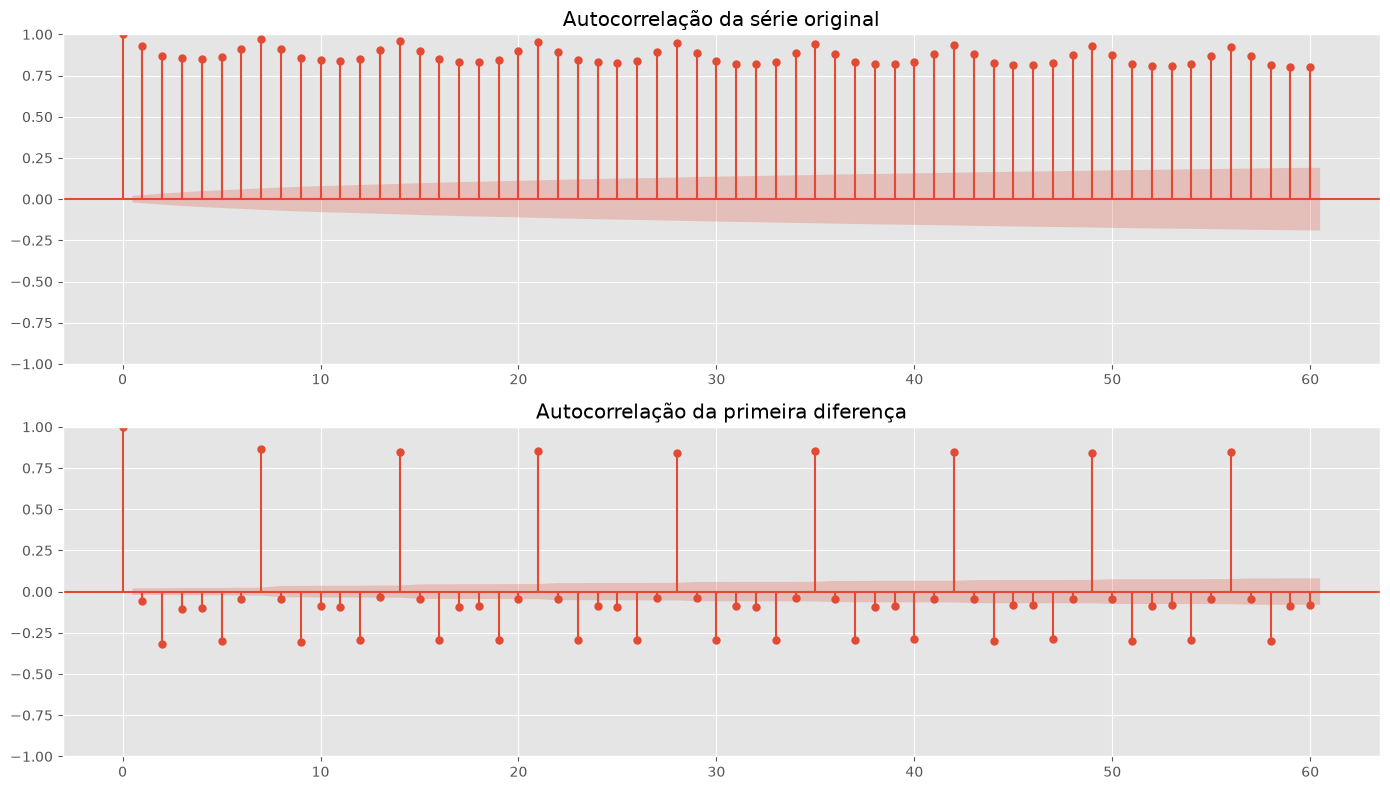

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_series, lags=60, ax=axes[0], title='Autocorrelação da série original')
plot_acf(first_difference, lags=60, ax=axes[1], title='Autocorrelação da primeira diferença')

plt.tight_layout()
plt.show()


- Na série original, as correlações permanecem elevadas em várias defasagens. O valor foi de 0,932 no primeiro dia e 0,972 na defasagem de sete dias.

- Depois da primeira diferença, as correlações de curto prazo diminuem, mas a defasagem de sete dias permanece elevada, com 0,868. O mesmo comportamento aparece nos múltiplos de sete, como 14, 21 e 28 dias.

- Portanto, a tendência explica uma parte da dependência da série original, mas existe uma estrutura semanal persistente mesmo quando analisamos as mudanças diárias.

## 6. Testes de Estacionariedade

Os gráficos indicaram mudanças de média e variabilidade. Agora essa característica será avaliada com dois testes que possuem hipóteses nulas opostas:

- **ADF:** considera inicialmente que a série possui raiz unitária e não é estacionária;
- **KPSS:** considera inicialmente que a série é estacionária.

Será adotado o nível de significância de 5%. Os testes serão aplicados à série original e à primeira diferença.


In [25]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        'Série diária original e sua média móvel',
        'Primeira diferença e sua média móvel'
    ),
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(
        x=daily_series.index,
        y=daily_series,
        name='Carga diária',
        line=dict(color='lightsteelblue', width=1)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=daily_series.index,
        y=daily_series.rolling(365).mean(),
        name='Média móvel de 365 dias',
        line=dict(color='#636EFA', width=2)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=first_difference.index,
        y=first_difference,
        name='Variação diária',
        line=dict(color='lightgray', width=1)
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=first_difference.index,
        y=first_difference.rolling(30).mean(),
        name='Média móvel de 30 dias',
        line=dict(color='#EF553B', width=2)
    ),
    row=2,
    col=1
)

fig.add_hline(y=0, line_color='black', row=2, col=1)
fig.update_yaxes(title_text='Carga média (MWmed)', row=1, col=1)
fig.update_yaxes(title_text='Variação diária (MWmed)', row=2, col=1)
fig.update_xaxes(title_text='Ano', row=2, col=1)
fig.update_layout(height=750, hovermode='x unified')
fig.show()


- A média móvel da série original apresenta mudanças claras de nível. Já a média móvel da primeira diferença oscila ao redor de zero e não mantém a tendência crescente visível no gráfico superior.

- Essa observação visual ainda não é suficiente para classificar as séries. Os testes serão executados a seguir.


In [26]:
def stationarity_tests(series):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        warnings.simplefilter('ignore', InterpolationWarning)

        adf_result = adfuller(series, autolag='AIC')
        kpss_result = kpss(series, regression='c', nlags='auto')

    return pd.Series({
        'estatistica_adf': adf_result[0],
        'p_valor_adf': adf_result[1],
        'estatistica_kpss': kpss_result[0],
        'p_valor_kpss': kpss_result[1]
    })


stationarity_results = pd.DataFrame({
    'serie_original': stationarity_tests(daily_series),
    'primeira_diferenca': stationarity_tests(first_difference)
}).T

stationarity_results.round(4)


,estatistica_adf,p_valor_adf,estatistica_kpss,p_valor_kpss
serie_original,-1.4486,0.5588,14.7509,0.01
primeira_diferenca,-20.9664,0.0000,0.0084,0.10


- Na série original, o teste ADF apresentou p-valor de 0,5588. Como o resultado é maior que 5%, não rejeitamos a hipótese de raiz unitária. O KPSS apresentou p-valor de 0,01, levando à rejeição da hipótese de estacionariedade.

- Os dois testes apontam, portanto, que a série diária original não é estacionária.

- Na primeira diferença, o ADF apresentou p-valor inferior a 0,0001 e o KPSS apresentou 0,10. Nesse caso, o ADF rejeita a presença de raiz unitária e o KPSS não rejeita a estacionariedade.

- Os resultados indicam que a primeira diferença removeu a principal fonte de não estacionariedade detectada pelos testes. Os valores de 0,01 e 0,10 do KPSS representam os limites da tabela de referência utilizada pela implementação, e não estimativas exatas além desses limites.

## 7. Diagnóstico dos Resíduos da Decomposição

O resíduo representa a parcela que permaneceu depois da retirada da tendência e das sazonalidades semanal e anual.

Primeiro serão verificadas suas medidas estatísticas e sua distribuição. Em seguida, serão localizados os maiores desvios e analisada sua autocorrelação.


In [27]:
residuals = decomposition.resid

residual_summary = residuals.describe()
residual_summary.loc['assimetria'] = residuals.skew()
residual_summary.loc['curtose'] = residuals.kurt()

residual_summary.round(2)

count          9497.00
mean           -208.14
std            2262.54
min          -16950.29
25%            -883.92
50%              -1.74
75%             777.81
max           13486.50
assimetria       -0.90
curtose           6.80
Name: resid, dtype: float64

In [28]:
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        'Resíduos da decomposição ao longo do tempo',
        'Distribuição dos resíduos'
    ),
    vertical_spacing=0.15
)

fig.add_trace(
    go.Scatter(
        x=residuals.index,
        y=residuals,
        name='Resíduo',
        line=dict(color='#EF553B', width=1)
    ),
    row=1,
    col=1
)

fig.add_hline(y=0, line_color='black', row=1, col=1)

fig.add_trace(
    go.Histogram(
        x=residuals,
        nbinsx=50,
        name='Distribuição',
        marker_color='#EF553B',
        marker_line_color='black',
        marker_line_width=0.5
    ),
    row=2,
    col=1
)

fig.update_yaxes(title_text='Resíduo (MWmed)', row=1, col=1)
fig.update_xaxes(title_text='Ano', row=1, col=1)
fig.update_xaxes(title_text='Resíduo (MWmed)', row=2, col=1)
fig.update_yaxes(title_text='Quantidade de dias', row=2, col=1)
fig.update_layout(height=750, showlegend=False)
fig.show()


- A mediana dos resíduos ficou próxima de zero, mas a média foi de aproximadamente -208 MWmed. A assimetria de -0,90 mostra uma cauda mais longa do lado negativo, e a curtose de 6,80 indica maior concentração de valores extremos do que seria esperado em uma distribuição normal.

- O gráfico também mostra períodos com desvios acentuados. Para identificar quando eles ocorreram, serão listados os 15 maiores resíduos em valor absoluto.


In [29]:
largest_residuals = residuals.abs().nlargest(15).index

residual_extremes = pd.DataFrame({
    'residuo': residuals.loc[largest_residuals],
    'valor_absoluto': residuals.loc[largest_residuals].abs(),
    'dia_semana': largest_residuals.day_name()
}).sort_values('valor_absoluto', ascending=False)

residual_extremes.round(2)

,residuo,valor_absoluto,dia_semana
din_instante,,,
2020-04-10,-16950.29,16950.29,Friday
2024-03-29,-14834.98,14834.98,Friday
2014-12-25,-14246.97,14246.97,Thursday
2023-04-07,-13673.00,13673.00,Friday
2018-05-31,-13636.46,13636.46,Thursday
2013-03-29,-13529.16,13529.16,Friday
2023-11-17,13486.50,13486.50,Friday
2015-04-03,-13356.70,13356.70,Friday
2025-12-31,13046.57,13046.57,Wednesday


- A maior diferença entre o valor observado e os componentes estimados ocorreu em 10/04/2020, com resíduo negativo de aproximadamente 16.950 MWmed.

- Entre os maiores resíduos negativos aparecem datas como 25 de dezembro e várias sextas-feiras entre março e abril. O resultado não identifica automaticamente a causa desses desvios, mas mostra que existem efeitos de calendário ou acontecimentos específicos que não foram representados apenas pelas sazonalidades semanal e anual.

- Por fim, será verificado se os resíduos ainda possuem dependência temporal.


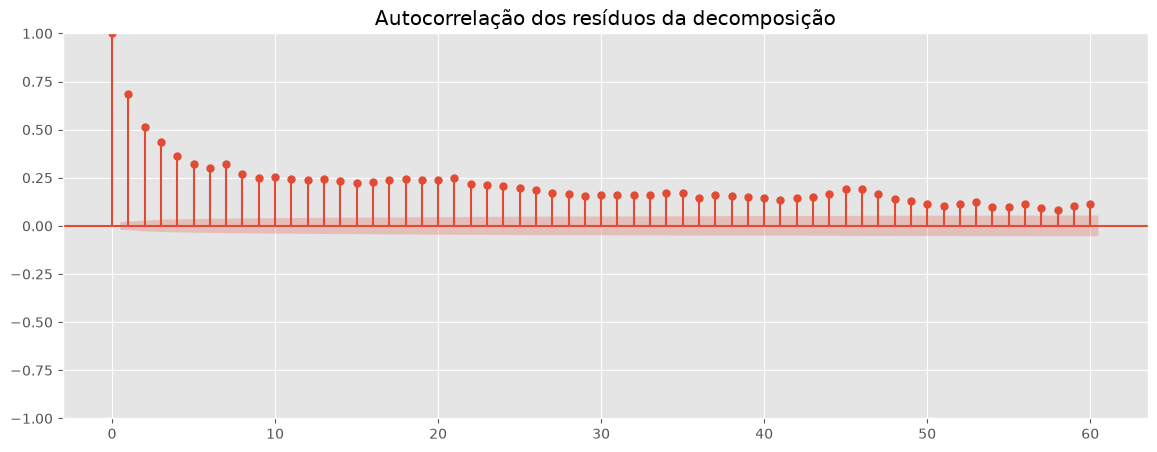

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(residuals, lags=60, ax=ax, title='Autocorrelação dos resíduos da decomposição')

plt.show()


In [31]:
residual_lags = [1, 2, 3, 7, 14, 21, 30]

residual_autocorrelation = pd.Series(
    {lag: residuals.autocorr(lag) for lag in residual_lags}, name='autocorrelacao'
)

residual_autocorrelation.index.name = 'defasagem_dias'

residual_autocorrelation.round(3)


defasagem_dias
1     0.685
2     0.514
3     0.436
7     0.323
14    0.234
21    0.250
30    0.160
Name: autocorrelacao, dtype: float64

- A correlação com o dia anterior foi de 0,685 e a defasagem semanal apresentou 0,323.

- Para verificar em conjunto se essas correlações podem ser consideradas iguais a zero, será aplicado o teste de Ljung–Box nas defasagens 7 e 30. Sua hipótese nula afirma que não existe autocorrelação até a defasagem avaliada.


In [32]:
ljung_box_result = acorr_ljungbox(residuals, lags=[7, 30], return_df=True)
ljung_box_result.index.name = 'defasagem_dias'

ljung_box_result.round(4)


,lb_stat,lb_pvalue
defasagem_dias,,
7,12795.5948,0.0
30,23612.4923,0.0


- Nos dois limites avaliados, o p-valor foi inferior a 0,0001. Assim, o teste rejeita a hipótese de ausência de autocorrelação.

- Portanto, a decomposição retirou componentes importantes, mas não transformou os resíduos em uma sequência completamente aleatória. Ainda existem relações entre dias consecutivos e uma parcela menor da estrutura semanal.

- Como o objetivo deste projeto não inclui modelagem, essa dependência não será utilizada para construir previsões. Ela será registrada como uma característica estatística da série.

## 8. Conclusões do Diagnóstico Temporal

O diagnóstico foi construído em etapas, e os resultados permitem concluir que:

- A agregação produziu uma série com 9.497 dias;
- Três dias completamente ausentes foram preenchidos pela média do mesmo dia da semana anterior e posterior, após a comparação com a interpolação linear;
- Dezenove dias com 23 horas válidas foram preservados, pois estão relacionados às transições de horário de verão investigadas anteriormente;
- A média e o desvio-padrão móveis mudam ao longo do tempo;
- A correlação de 0,880 entre média e desvio-padrão móveis mostra que a dispersão absoluta tende a crescer com o nível da carga;
- A decomposição separou uma tendência, um componente semanal e um componente anual;
- A autocorrelação permanece elevada nas defasagens múltiplas de sete, inclusive depois da primeira diferença;
- Os testes ADF e KPSS classificaram a série original como não estacionária;
- Depois da primeira diferença, os dois testes passaram a indicar estacionariedade;
- Os resíduos possuem assimetria negativa, valores extremos e autocorrelação remanescente;
- Algumas das maiores diferenças residuais se concentram em datas que devem ser comparadas futuramente com feriados e eventos externos.
